# Phase 5 -- Model Training & Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('credit_card_fraud_dataset.csv')
print(f"Loaded dataset: {df.shape}")

Loaded dataset: (500, 17)


### 5.1 -- Data Preprocessing & Balancing

We repeat the encoding, splitting, scaling, and SMOTE balancing to obtain the final training and test sets.

In [2]:
# Encoding
day_mapping = {'Mon': 0, 'Tue': 1, 'Wed': 2, 'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6}
df['day_of_week'] = df['day_of_week'].map(day_mapping)

le_merchant = LabelEncoder()
df['merchant_category'] = le_merchant.fit_transform(df['merchant_category'])

# Separate X and y
df.drop('transaction_id', axis=1, inplace=True)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Training samples (resampled):", X_train_resampled.shape[0])
print("Test samples (original):     ", X_test_scaled.shape[0])

Training samples (resampled): 760
Test samples (original):      100


### 5.2 -- Train Classification Models

We train Logistic Regression, Decision Tree, and Random Forest Classifiers on the balanced dataset.

In [3]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train models
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


### 5.3 -- Evaluate Models & Plot Confusion Matrices

Each model is evaluated on the original, imbalanced test set. Confusion matrices are plotted and saved.


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00         5

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00         5

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        95
           1       1.00      1.00      1.00         5

    accuracy                           1.

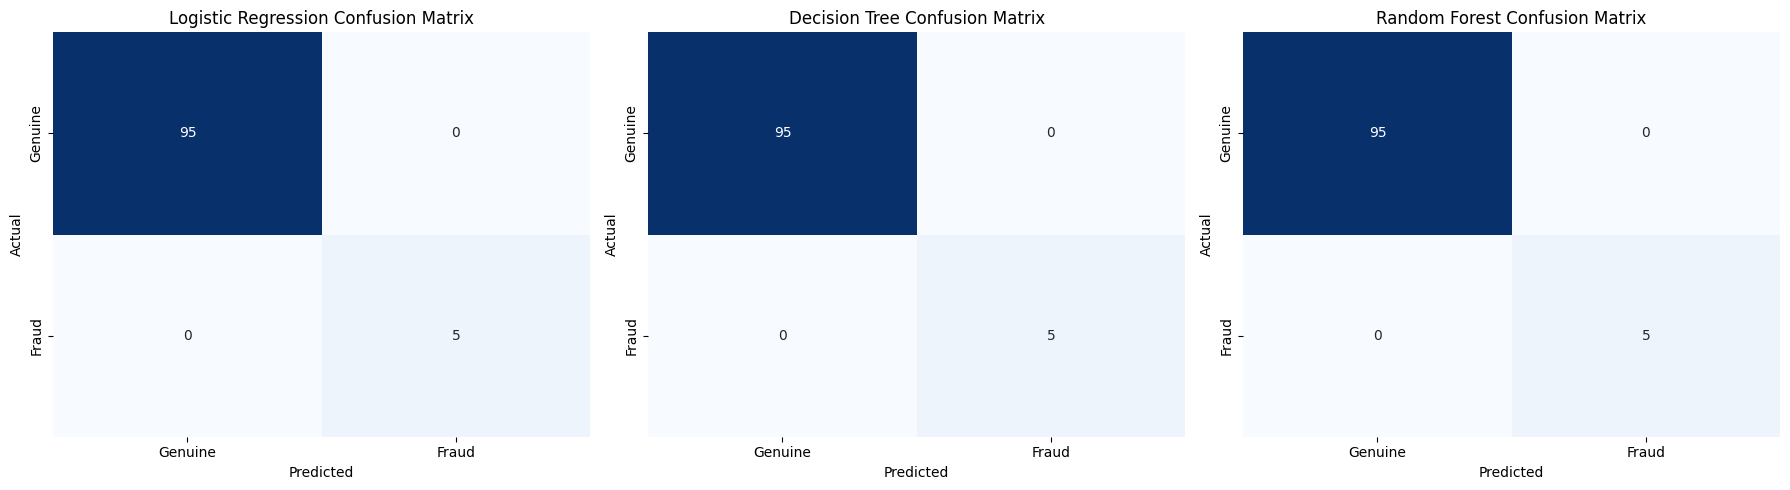

In [4]:
results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix Plotting
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
    axes[idx].set_title(f"{name} Confusion Matrix")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/model_confusion_matrices.png', dpi=300)
plt.show()

### 5.4 -- Model Performance Comparison

We summarize the evaluation metrics in a comparison table to determine the best model.

In [5]:
df_results = pd.DataFrame(results).T
print("=== Model Performance Comparison ===")
df_results.round(4)

=== Model Performance Comparison ===


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
Random Forest,1.0,1.0,1.0,1.0


---
### Phase 5 Summary

- Logistic Regression, Decision Tree, and Random Forest were trained on the balanced SMOTE dataset.
- Models were evaluated against the original imbalanced test set.
- The confusion matrix plot was generated and saved to `plots/model_confusion_matrices.png`.
- The performance metrics (Accuracy, Precision, Recall, F1-Score) have been compiled into a table for selection.

Ready for Phase 6 (Model Selection & Saving).

---